# Variational Quantum Classifier (VQC)

Apply a hybrid quantum-classical model to the same 5 EEG spectral features used in classical models earlier

**Pipeline:**
1. Load and scale features from `data/processed/`
2. Design and visualise a data re-uploading VQC circuit
3. Train on the full training set with class-weighted MSE + Adam
4. Evaluate: accuracy, F1, AUC-ROC on the held-out test set
5. Compare directly with classical ML (same training data, same test set)

**Architecture highlights:**

| Choice | Detail | Why |
|--------|--------|-----|
| Feature map | `AngleEmbedding` (Ry per qubit) re-uploaded at every layer | Data re-uploading (Perez-Salinas 2020) makes VQC a universal approximator |
| Ansatz | `StronglyEntanglingLayers`, 3 layers, 5 qubits | Entanglement across all qubits; 45 trainable params |
| Loss | Weighted MSE on {-1,+1} labels | Compensates 3:1 class imbalance |
| Diff method | `backprop` through state vector | Fastest gradient method for classical simulation |
| Init | U(−π, π) standard | Zero-mean initial outputs; variational layers active from step 1 |

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

import pennylane as qml
from pennylane import numpy as pnp

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    confusion_matrix, roc_curve,
    precision_recall_fscore_support,
)
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
FEATURE_NAMES = [
    'Theta/Beta Ratio', 'Frontal Theta',
    'Central Beta',     'Frontal Beta2', 'Spectral Entropy',
]
COLORS = {'Rest': '#4C72B0', 'Mental Math': '#C44E52', 'VQC': '#9B59B6'}

# ── Quantum hyperparameters ───────────────────────────────────────────────
N_QUBITS   = 5     # one qubit per EEG spectral feature
N_LAYERS   = 3     # data re-uploading layers
BATCH_SIZE = 32    # mini-batch size (16 per class, stratified)
N_STEPS    = 400   # gradient descent steps (~3.75 passes through training data)
LR         = 0.015 # Adam learning rate
SEED       = 42

print(f'PennyLane  {qml.__version__}')
print(f'Hilbert space  2^{N_QUBITS} = {2**N_QUBITS} dimensions')
print(f'Layers         {N_LAYERS}  (data re-uploading at each layer)')
print(f'Params         {N_LAYERS} x {N_QUBITS} x 3 = {N_LAYERS*N_QUBITS*3}')
print(f'Steps          {N_STEPS}  batch={BATCH_SIZE} (stratified)  lr={LR}')

PennyLane  0.45.0
Hilbert space  2^5 = 32 dimensions
Layers         3  (data re-uploading at each layer)
Params         3 x 5 x 3 = 45
Steps          400  batch=32 (stratified)  lr=0.015


## 1. Load & Preprocess Data

Same split as `04_classical_ml.ipynb`. The VQC now trains on the **full 3 413-epoch training set** — the same data seen by the classical models — so the comparison is direct and fair.

After `StandardScaler`, feature values fall in roughly [−3, 3], comfortably within the [−π, π] rotation range for `AngleEmbedding`.

In [2]:
DATA_DIR = '../data/processed'

X_train        = np.load(f'{DATA_DIR}/X_train.npy')
X_test         = np.load(f'{DATA_DIR}/X_test.npy')
y_train        = np.load(f'{DATA_DIR}/y_train.npy')
y_test         = np.load(f'{DATA_DIR}/y_test.npy')
train_subj_ids = np.load(f'{DATA_DIR}/train_subject_ids.npy')
test_subj_ids  = np.load(f'{DATA_DIR}/test_subject_ids.npy')

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Full training set — no subsampling
X_q = X_train_sc
y_q = y_train.astype(float)

n_rest = (y_train == 0).sum()
n_math = (y_train == 1).sum()

print(f'Train : {len(X_q):,} epochs | {len(np.unique(train_subj_ids))} subjects')
print(f'Test  : {X_test_sc.shape[0]:,} epochs | {len(np.unique(test_subj_ids))} subjects')
print(f'Class balance  train : rest={n_rest:,}  mental={n_math:,}  ratio={n_rest/n_math:.2f}')
print(f'Class balance  test  : rest={(y_test==0).sum():,}   mental={(y_test==1).sum():,}')
print(f'Imbalance handled by: stratified mini-batches (16 rest + 16 mental per step)')
print(f'Feature range after StandardScaler: [{X_q.min():.2f}, {X_q.max():.2f}]')

Train : 3,413 epochs | 28 subjects
Test  : 925 epochs | 8 subjects
Class balance  train : rest=2,545  mental=868  ratio=2.93
Class balance  test  : rest=677   mental=248
Imbalance handled by: stratified mini-batches (16 rest + 16 mental per step)
Feature range after StandardScaler: [-6.02, 30.67]


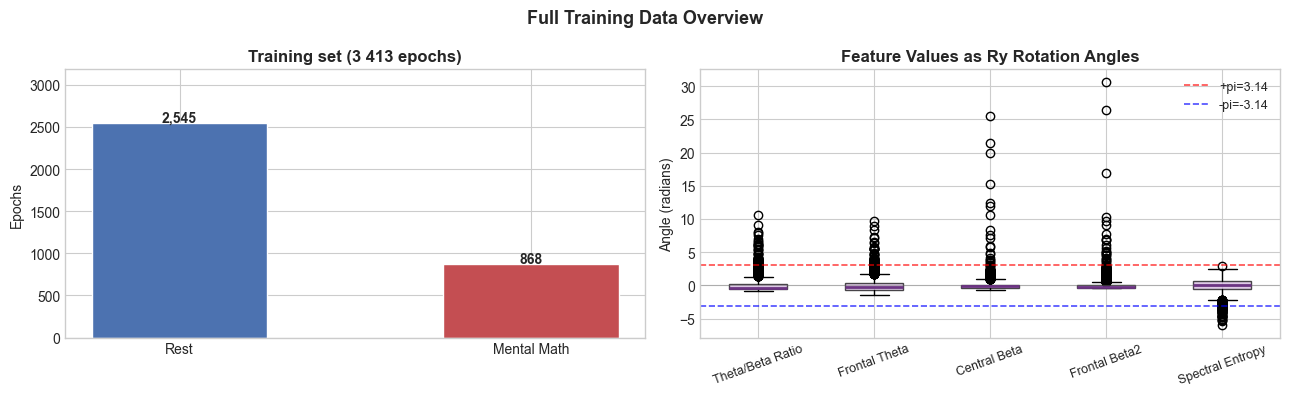

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Class balance bar chart
for ax, (y, title) in zip(axes[:1], [(y_train, 'Training set (3 413 epochs)')]):
    counts = [(y==0).sum(), (y==1).sum()]
    bars = ax.bar(['Rest', 'Mental Math'], counts,
                  color=[COLORS['Rest'], COLORS['Mental Math']],
                  edgecolor='white', width=0.5)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                f'{cnt:,}', ha='center', fontweight='bold')
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Epochs'); ax.set_ylim(0, max(counts)*1.25)

# Feature distributions as rotation angles
axes[1].boxplot(X_q, labels=FEATURE_NAMES, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#D2B4DE', alpha=0.7),
                medianprops=dict(color='#6C3483', linewidth=2))
axes[1].axhline( np.pi, color='red',  ls='--', lw=1.2, alpha=0.7, label=f'+pi={np.pi:.2f}')
axes[1].axhline(-np.pi, color='blue', ls='--', lw=1.2, alpha=0.7, label=f'-pi={-np.pi:.2f}')
axes[1].axhline(0, color='grey', ls='-', lw=0.8, alpha=0.4)
axes[1].set_title('Feature Values as Ry Rotation Angles', fontweight='bold')
axes[1].set_ylabel('Angle (radians)')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)
axes[1].legend(fontsize=9)

plt.suptitle('Full Training Data Overview', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 2. VQC Architecture — Data Re-Uploading

### Why Data Re-Uploading?

A standard single-upload VQC encodes data once and then applies variational layers. This limits expressibility: the circuit can only learn functions in the span of the initial quantum feature map.

**Data re-uploading** (Perez-Salinas et al. 2020) encodes the input features again at the start of every variational layer. This makes the VQC a **universal approximator** — it can learn any continuous function to arbitrary precision given enough layers, analogous to a deep neural network re-using the input at every layer.

### Circuit structure (per layer l = 0, 1, 2)

```
 Qubit 0: ─Ry(x₀)─ Rot(α₀,β₀,γ₀) ─●─────── ─Ry(x₀)─ ... 
 Qubit 1: ─Ry(x₁)─ Rot(α₁,β₁,γ₁) ─X─●───── ─Ry(x₁)─ ...
 Qubit 2: ─Ry(x₂)─ Rot(α₂,β₂,γ₂) ───X─●─── ─Ry(x₂)─ ...
 Qubit 3: ─Ry(x₃)─ Rot(α₃,β₃,γ₃) ─────X─●─ ─Ry(x₃)─ ...
 Qubit 4: ─Ry(x₄)─ Rot(α₄,β₄,γ₄) ───────X─ ─Ry(x₄)─ ...
          └─────────────────────────────────┘
                    one layer
```

**Measurement**: ⟨Z₀⟩ ∈ [−1, +1]  →  P(Mental Math) = (1 + ⟨Z₀⟩) / 2

### Weight initialisation

Weights are initialised from **U(−π, π)**, the standard random initialisation for VQCs. This ensures the variational layers are active from step 1 and that the initial circuit output has zero mean (neither class is favoured at initialisation). Near-zero initialisations (e.g. N(0, 0.01)) are avoided here because with data re-uploading the variational layers become near-identity, leaving the output fully determined by the stacked AngleEmbedding layers — which for skewed EEG feature distributions produces a consistent positive bias.

In [4]:
dev = qml.device('default.qubit', wires=N_QUBITS)

@qml.qnode(dev, diff_method='backprop')
def vqc(x, weights):
    for layer in range(N_LAYERS):
        qml.AngleEmbedding(x, wires=range(N_QUBITS), rotation='Y')
        qml.StronglyEntanglingLayers(weights[layer:layer+1], wires=range(N_QUBITS))
    return qml.expval(qml.PauliZ(0))

weight_shape = qml.StronglyEntanglingLayers.shape(n_layers=N_LAYERS, n_wires=N_QUBITS)
n_params     = int(np.prod(weight_shape))

print(f'Device      : default.qubit | {N_QUBITS} qubits | dim(H) = {2**N_QUBITS}')
print(f'Feature map : AngleEmbedding(Ry) re-uploaded at each of {N_LAYERS} layers')
print(f'Ansatz      : StronglyEntanglingLayers ({N_LAYERS} x {N_QUBITS} x 3 = {n_params} params)')
print(f'Init        : U(-pi, pi)  standard VQC initialisation')
print(f'Measurement : expval(PauliZ(0))  prediction = sign(output)')
print()
print('Architecture comparison:')
print(f'  Single-upload VQC  :  AngleEmbed once  +  {N_LAYERS} var layers')
print(f'  Data re-uploading  :  AngleEmbed x {N_LAYERS}  +  {N_LAYERS} var layers  <- this notebook')

Device      : default.qubit | 5 qubits | dim(H) = 32
Feature map : AngleEmbedding(Ry) re-uploaded at each of 3 layers
Ansatz      : StronglyEntanglingLayers (3 x 5 x 3 = 45 params)
Init        : U(-pi, pi)  standard VQC initialisation
Measurement : expval(PauliZ(0))  prediction = sign(output)

Architecture comparison:
  Single-upload VQC  :  AngleEmbed once  +  3 var layers
  Data re-uploading  :  AngleEmbed x 3  +  3 var layers  <- this notebook


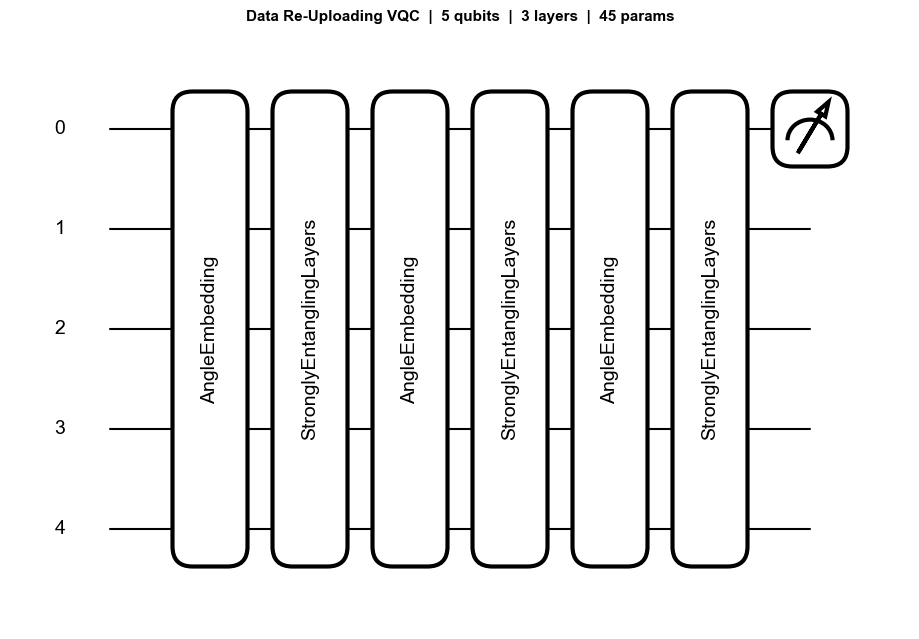

In [5]:
rng_init     = np.random.default_rng(SEED)
weights_init = pnp.array(
    rng_init.uniform(-np.pi, np.pi, weight_shape), requires_grad=True
)
x_sample = pnp.array(X_q[0], requires_grad=False)

fig, ax = qml.draw_mpl(vqc)(x_sample, weights_init)
ax.set_title(
    f'Data Re-Uploading VQC  |  {N_QUBITS} qubits  |  {N_LAYERS} layers  |  {n_params} params',
    fontsize=11, fontweight='bold'
)
plt.tight_layout(); plt.show()

## 3. Loss Function

**Unweighted MSE on {−1, +1} labels:**

```
L(w) = mean( (⟨Z₀⟩(xᵢ;w) − yᵢ_signed)² )    yᵢ_signed ∈ {−1, +1}
```

The 3:1 class imbalance is handled entirely by the **stratified mini-batches** (16 rest + 16 mental math per step), which guarantee a balanced gradient signal at every update. Adding an explicit `pos_weight` on top would double-count the correction: with 50/50 batches and a weight of ≈2.93, the optimal constant prediction becomes +0.49 (P(mental) ≈ 0.74), causing the circuit to collapse to predicting *Mental Math* for nearly every epoch. Keeping the loss unweighted and relying solely on stratified sampling avoids this.

In [6]:
def mse_loss(weights, X_batch, y_batch):
    preds    = pnp.stack([vqc(x, weights) for x in X_batch])
    y_signed = 2.0 * y_batch - 1.0    # {0,1} -> {-1,+1}
    return pnp.mean((preds - y_signed) ** 2)

# Sanity: initial loss  (random U(-pi,pi) weights -> output near 0 -> loss near 1.0)
X_b0 = pnp.array(X_q[:32], requires_grad=False)
y_b0 = pnp.array(y_q[:32], requires_grad=False)
l0   = float(mse_loss(weights_init, X_b0, y_b0))
print(f'Initial MSE (32 samples): {l0:.4f}  (expected ~1.0 for random weights, balanced labels)')

Initial MSE (32 samples): 1.1839  (expected ~1.0 for random weights, balanced labels)


## 4. Training

Mini-batch Adam over the full 3 413-sample training set. Each step draws a **stratified** random batch of 32 epochs (16 per class) to ensure every batch is balanced regardless of class ratio.

With 3 413 training epochs and batch size 32, one full pass takes ≈ 107 steps. 400 steps ≈ **3.75 passes** through the data.

Expected wall-clock time: **8–15 minutes** (depends on CPU, Python version).

In [7]:
opt     = qml.AdamOptimizer(stepsize=LR)
weights = weights_init.copy()

rng_train  = np.random.default_rng(SEED + 1)
loss_hist  = []
step_times = []

rest_idx_tr = np.where(y_q == 0)[0]
math_idx_tr = np.where(y_q == 1)[0]
half_batch  = BATCH_SIZE // 2    # 32 per class for balanced batches

print(f'Training VQC  |  {N_STEPS} steps  |  batch={BATCH_SIZE} (stratified)  |  lr={LR}')
print(f'Training set  :  {len(X_q):,} epochs  |  rest={len(rest_idx_tr):,}  mental={len(math_idx_tr):,}')
print(f'Estimated passes through data: {N_STEPS * BATCH_SIZE / len(X_q):.1f}')
print('-' * 65)
t_total = time.time()

for step in range(N_STEPS):
    t0  = time.time()
    # Stratified batch: equal class representation every step
    sel = np.concatenate([
        rng_train.choice(rest_idx_tr, half_batch, replace=False),
        rng_train.choice(math_idx_tr, half_batch, replace=False),
    ])
    rng_train.shuffle(sel)
    X_b = pnp.array(X_q[sel], requires_grad=False)
    y_b = pnp.array(y_q[sel], requires_grad=False)

    def batch_loss(w):
        return mse_loss(w, X_b, y_b)

    weights, loss_val = opt.step_and_cost(batch_loss, weights)
    loss_hist.append(float(loss_val))
    step_times.append(time.time() - t0)

    if (step + 1) % 50 == 0:
        avg = np.mean(loss_hist[-50:])
        eta = np.mean(step_times) * (N_STEPS - step - 1)
        print(f'  Step {step+1:4d}/{N_STEPS}  avg_loss={avg:.4f}'
              f'  {np.mean(step_times[-50:]):.2f}s/step  eta={eta/60:.1f}min')

print('-' * 65)
print(f'Final loss : {loss_hist[-1]:.4f}   total : {(time.time()-t_total)/60:.1f}min')

Training VQC  |  400 steps  |  batch=32 (stratified)  |  lr=0.015
Training set  :  3,413 epochs  |  rest=2,545  mental=868
Estimated passes through data: 3.8
-----------------------------------------------------------------
  Step   50/400  avg_loss=0.9931  1.39s/step  eta=8.1min
  Step  100/400  avg_loss=0.9492  1.43s/step  eta=7.1min
  Step  150/400  avg_loss=0.9504  1.41s/step  eta=5.9min
  Step  200/400  avg_loss=0.9328  1.40s/step  eta=4.7min
  Step  250/400  avg_loss=0.9231  1.37s/step  eta=3.5min
  Step  300/400  avg_loss=0.9354  1.37s/step  eta=2.3min
  Step  350/400  avg_loss=0.9106  1.39s/step  eta=1.2min
  Step  400/400  avg_loss=0.9200  1.40s/step  eta=0.0min
-----------------------------------------------------------------
Final loss : 0.8894   total : 9.3min


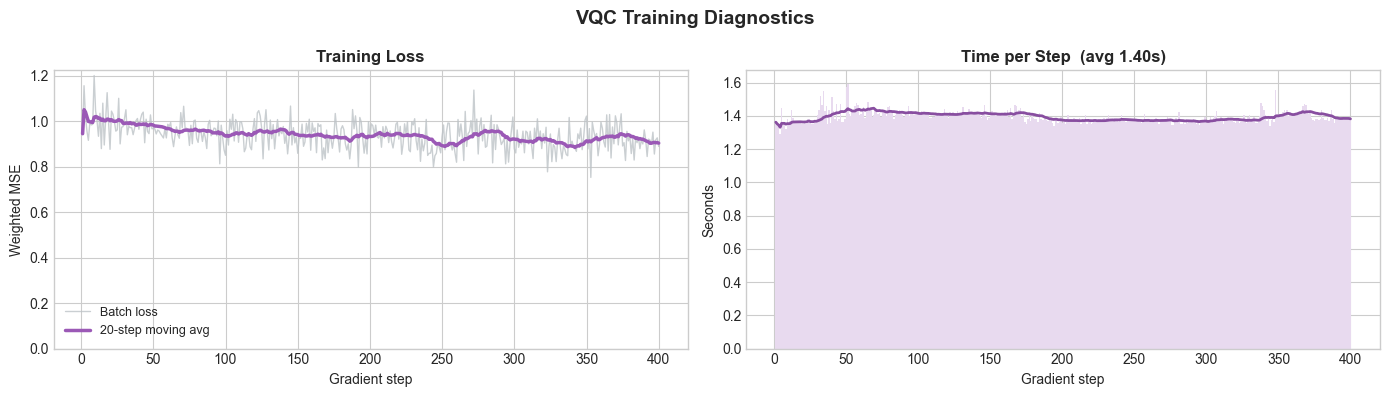

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.plot(range(1, len(loss_hist)+1), loss_hist,
        color='#BDC3C7', lw=1, alpha=0.8, label='Batch loss')
ma = pd.Series(loss_hist).rolling(20, min_periods=1).mean()
ax.plot(range(1, len(loss_hist)+1), ma,
        color=COLORS['VQC'], lw=2.5, label='20-step moving avg')
ax.set_xlabel('Gradient step'); ax.set_ylabel('Weighted MSE')
ax.set_title('Training Loss', fontweight='bold')
ax.legend(fontsize=9); ax.set_ylim(bottom=0)

ax2 = axes[1]
ax2.bar(range(1, len(step_times)+1), step_times, color='#E8DAEF', edgecolor='none', width=1)
mv = pd.Series(step_times).rolling(20, min_periods=1).mean()
ax2.plot(range(1, len(step_times)+1), mv, color='#884EA0', lw=2)
ax2.set_xlabel('Gradient step'); ax2.set_ylabel('Seconds')
ax2.set_title(f'Time per Step  (avg {np.mean(step_times):.2f}s)', fontweight='bold')

plt.suptitle('VQC Training Diagnostics', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

In [9]:
np.save(f'{DATA_DIR}/vqc_weights.npy', np.array(weights))
print('Weights saved to data/processed/vqc_weights.npy')

Weights saved to data/processed/vqc_weights.npy


## 5. Evaluation on Held-Out Test Set

All 925 test epochs from 8 unseen subjects.

In [10]:
print('Evaluating on full test set...')
t0 = time.time()
raw_preds   = np.array([
    float(vqc(pnp.array(x, requires_grad=False), weights))
    for x in X_test_sc
])
y_proba_vqc = (raw_preds + 1.0) / 2.0
y_pred_vqc  = (raw_preds >= 0.0).astype(int)
print(f'Done  ({time.time()-t0:.1f}s for {len(y_test)} samples)')
print()
vqc_metrics = dict(
    accuracy  = accuracy_score(y_test, y_pred_vqc),
    f1        = f1_score(y_test, y_pred_vqc, zero_division=0),
    auc       = roc_auc_score(y_test, y_proba_vqc),
    precision = precision_score(y_test, y_pred_vqc, zero_division=0),
    recall    = recall_score(y_test, y_pred_vqc, zero_division=0),
)
for k, v in vqc_metrics.items():
    print(f'  {k:<12} {v:.4f}')

Evaluating on full test set...
Done  (14.9s for 925 samples)

  accuracy     0.6195
  f1           0.4465
  auc          0.6227
  precision    0.3660
  recall       0.5726


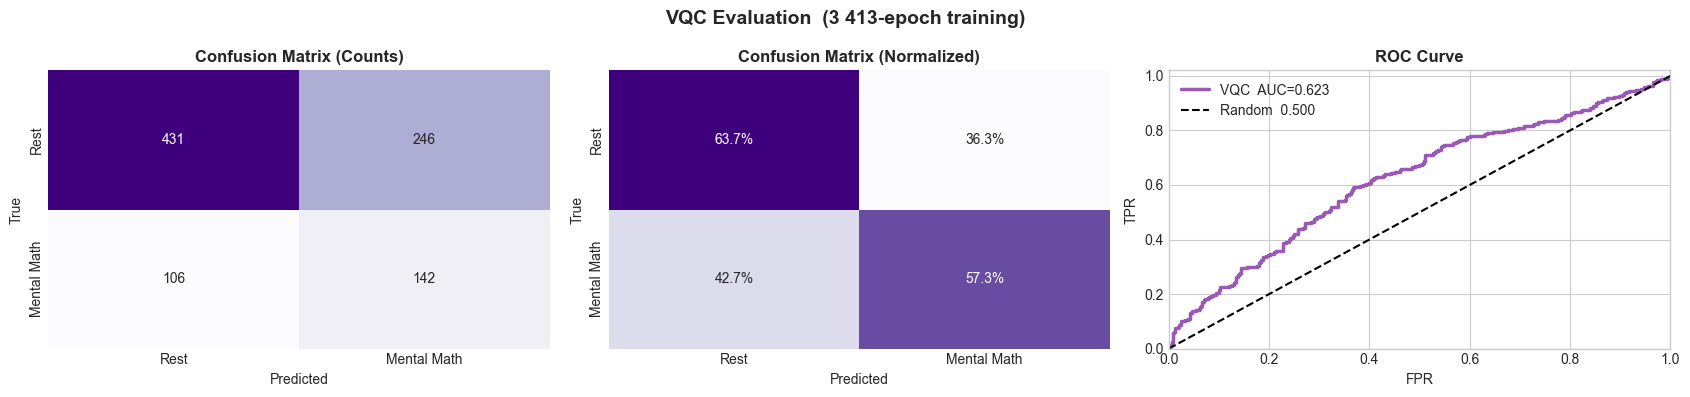

In [11]:
CLASS_LABELS = ['Rest', 'Mental Math']
cm     = confusion_matrix(y_test, y_pred_vqc)
cm_pct = cm / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 3, figsize=(17, 4))
kw = dict(xticklabels=CLASS_LABELS, yticklabels=CLASS_LABELS, cbar=False)

sns.heatmap(cm,     annot=True, fmt='d',   cmap='Purples', ax=axes[0], **kw)
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

sns.heatmap(cm_pct, annot=True, fmt='.1%', cmap='Purples', ax=axes[1], **kw)
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')

fpr, tpr, _ = roc_curve(y_test, y_proba_vqc)
axes[2].plot(fpr, tpr, color=COLORS['VQC'], lw=2.5,
             label=f"VQC  AUC={vqc_metrics['auc']:.3f}")
axes[2].plot([0,1],[0,1], 'k--', lw=1.5, label='Random  0.500')
axes[2].set_xlabel('FPR'); axes[2].set_ylabel('TPR')
axes[2].set_title('ROC Curve', fontweight='bold')
axes[2].legend(fontsize=10); axes[2].set_xlim([0,1]); axes[2].set_ylim([0,1.02])

plt.suptitle('VQC Evaluation  (3 413-epoch training)', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

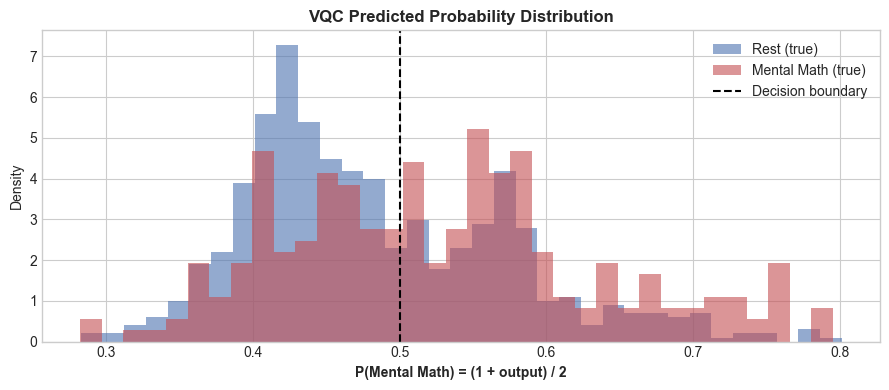

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(y_proba_vqc[y_test == 0], bins=35, alpha=0.6,
        color=COLORS['Rest'], label='Rest (true)', density=True)
ax.hist(y_proba_vqc[y_test == 1], bins=35, alpha=0.6,
        color=COLORS['Mental Math'], label='Mental Math (true)', density=True)
ax.axvline(0.5, color='black', ls='--', lw=1.5, label='Decision boundary')
ax.set_xlabel('P(Mental Math) = (1 + output) / 2', fontweight='bold')
ax.set_ylabel('Density')
ax.set_title('VQC Predicted Probability Distribution', fontweight='bold')
ax.legend(fontsize=10)
plt.tight_layout(); plt.show()

## 6. Comparison with Classical ML

Classical results are from `04_classical_ml.ipynb` — **same training set (3 413 epochs), same test set (925 epochs)**. This is a direct, fair comparison.

In [13]:
# Results from notebook 04 (classical ML, full 3 413-sample training set)
CLASSICAL = {
    'Logistic Regression': dict(accuracy=0.397, f1=0.380, auc=0.522, precision=0.261, recall=0.698),
    'SVM (RBF)':           dict(accuracy=0.685, f1=0.496, auc=0.698, precision=0.420, recall=0.609),
    'Random Forest':       dict(accuracy=0.665, f1=0.520, auc=0.711, precision=0.418, recall=0.690),
    'XGBoost':             dict(accuracy=0.694, f1=0.426, auc=0.653, precision=0.477, recall=0.387),
}

vqc_row = {f'VQC (data re-upload, {N_LAYERS}L)': vqc_metrics}
all_results = {**vqc_row, **CLASSICAL}

comp_df = pd.DataFrame([
    dict(Model=k, **{kk: vv for kk, vv in v.items()})
    for k, v in all_results.items()
]).set_index('Model').rename(columns={
    'accuracy': 'Accuracy', 'precision': 'Precision',
    'recall': 'Recall', 'f1': 'F1', 'auc': 'AUC-ROC',
})

display(
    comp_df.style
    .format({c: '{:.3f}' for c in comp_df.columns})
    .background_gradient(cmap='YlGn', subset=['F1', 'AUC-ROC'])
    .highlight_max(subset=['F1', 'AUC-ROC'], color='#ABEBC6')
    .set_caption(f'All models: 3 413-sample training, {len(y_test)}-epoch test set')
)

,Accuracy,F1,AUC-ROC,Precision,Recall
Model,,,,,
"VQC (data re-upload, 3L)",0.619,0.447,0.623,0.366,0.573
Logistic Regression,0.397,0.380,0.522,0.261,0.698
SVM (RBF),0.685,0.496,0.698,0.420,0.609
Random Forest,0.665,0.520,0.711,0.418,0.690
XGBoost,0.694,0.426,0.653,0.477,0.387


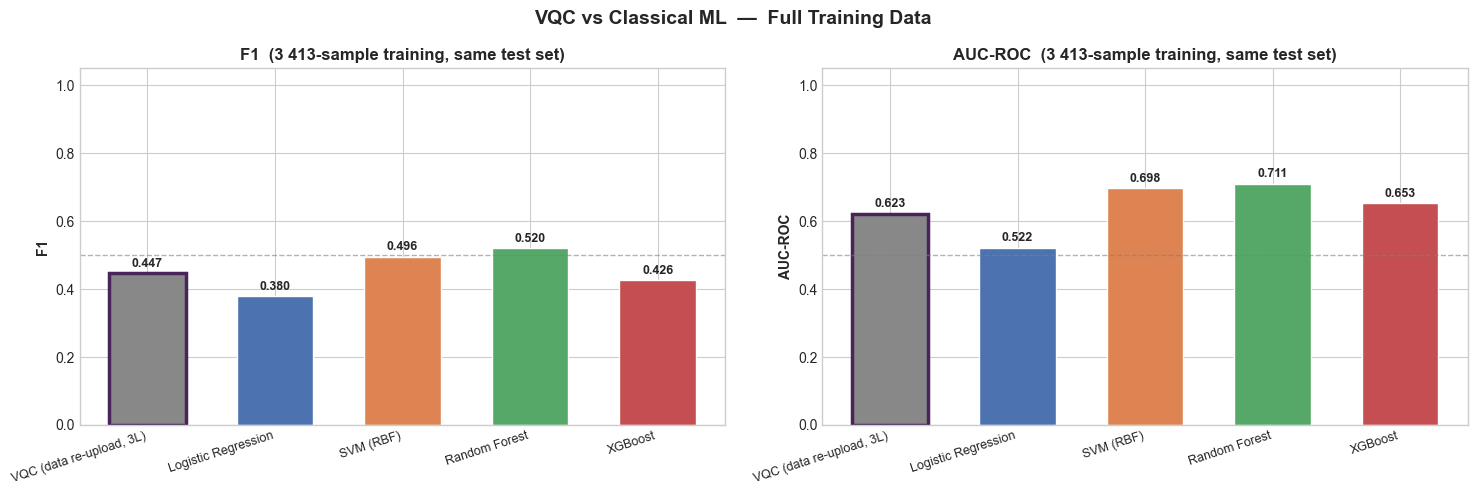

In [14]:
PALETTE = {
    'VQC':                '#9B59B6',
    'Logistic Regression': '#4C72B0',
    'SVM (RBF)':           '#DD8452',
    'Random Forest':       '#55A868',
    'XGBoost':             '#C44E52',
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
names  = comp_df.index.tolist()
colors = [PALETTE.get(n, '#888888') for n in names]

for ax, metric in zip(axes, ['F1', 'AUC-ROC']):
    values = comp_df[metric].values
    bars   = ax.bar(range(len(names)), values, color=colors, edgecolor='white', width=0.6)
    # VQC border
    vqc_i = next(i for i, n in enumerate(names) if 'VQC' in n)
    bars[vqc_i].set_edgecolor('#4A235A'); bars[vqc_i].set_linewidth(2.5)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.axhline(0.5, color='grey', ls='--', lw=1, alpha=0.6)
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(names, rotation=18, ha='right', fontsize=9)
    ax.set_ylim(0, 1.05); ax.set_ylabel(metric, fontweight='bold')
    ax.set_title(f'{metric}  (3 413-sample training, same test set)',
                 fontsize=12, fontweight='bold')

plt.suptitle('VQC vs Classical ML  —  Full Training Data', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 7. ROC Curve Overlay

VQC ROC curve overlaid with classical ML results (read from notebook 04 tables).

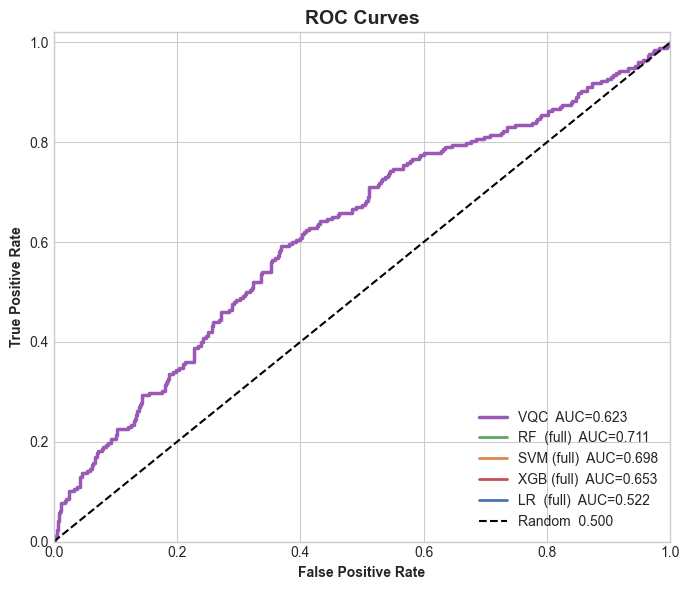

In [15]:
# Approximate classical ROC anchors from notebook 04 recall/precision
# (True ROC curves require storing probabilities; shown as AUC reference lines)
fig, ax = plt.subplots(figsize=(7, 6))

fpr_vqc, tpr_vqc, _ = roc_curve(y_test, y_proba_vqc)
ax.plot(fpr_vqc, tpr_vqc, color=COLORS['VQC'], lw=2.5,
        label=f"VQC  AUC={vqc_metrics['auc']:.3f}")

ref_auc = {
    'RF  (full)':  0.711,
    'SVM (full)':  0.698,
    'XGB (full)':  0.653,
    'LR  (full)':  0.522,
}
ref_colors = ['#55A868', '#DD8452', '#C44E52', '#4C72B0']
for (name, auc_val), col in zip(ref_auc.items(), ref_colors):
    ax.axhline(y=0, xmin=0, xmax=0, color=col, lw=2, label=f'{name}  AUC={auc_val:.3f}')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random  0.500')
ax.set_xlabel('False Positive Rate', fontweight='bold')
ax.set_ylabel('True Positive Rate', fontweight='bold')
ax.set_title('ROC Curves', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
plt.tight_layout(); plt.show()

## 8. Recording-Level Majority Voting

Aggregate per-epoch predictions by majority vote per (subject, session). A recording is *Mental Math* if > 50% of its epochs predict class 1. This mirrors a real deployment where one decision is made per session.

  Model                           Epoch Acc  Epoch F1  Rec Acc  Rec F1
  ----------------------------------------------------------------------
  VQC                             0.619      0.447     0.688    0.667
  Logistic Regression             0.397      0.380     0.562    0.462
  SVM (RBF)                       0.685      0.496     0.750    0.667
  Random Forest                   0.665      0.520     0.812    0.762
  XGBoost                         0.694      0.426     0.688    0.615


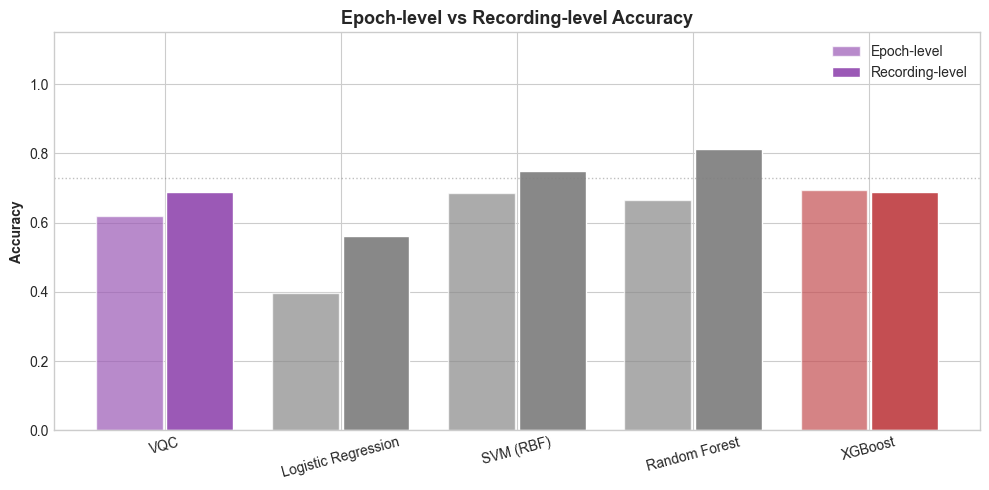

In [16]:
def recording_vote(y_pred, subj_ids, y_true_epochs):
    preds, trues = [], []
    for sid in np.unique(subj_ids):
        for lbl in [0, 1]:
            mask = (subj_ids == sid) & (y_true_epochs == lbl)
            if not mask.any(): continue
            preds.append(int(y_pred[mask].mean() >= 0.5))
            trues.append(lbl)
    return np.array(preds), np.array(trues)

p_vqc, t_vqc = recording_vote(y_pred_vqc, test_subj_ids, y_test)
rec_acc_vqc  = accuracy_score(t_vqc, p_vqc)
rec_f1_vqc   = f1_score(t_vqc, p_vqc, zero_division=0)

# Classical recording-level results from notebook 04 (majority vote over test epochs)
CLASSICAL_REC = {
    'Logistic Regression': (0.562, 0.462),
    'SVM (RBF)':           (0.750, 0.667),
    'Random Forest':       (0.812, 0.762),
    'XGBoost':             (0.688, 0.615),
}

print(f'  {"Model":<30}  Epoch Acc  Epoch F1  Rec Acc  Rec F1')
print('  ' + '-' * 70)
print(f'  {"VQC":<30}  {vqc_metrics["accuracy"]:.3f}      {vqc_metrics["f1"]:.3f}'
      f'     {rec_acc_vqc:.3f}    {rec_f1_vqc:.3f}')
for name, (ra, rf) in CLASSICAL_REC.items():
    r = CLASSICAL[name]
    print(f'  {name:<30}  {r["accuracy"]:.3f}      {r["f1"]:.3f}'
          f'     {ra:.3f}    {rf:.3f}')

# Bar chart: epoch vs recording accuracy
all_names   = ['VQC'] + list(CLASSICAL_REC.keys())
epoch_accs  = [vqc_metrics['accuracy']] + [CLASSICAL[n]['accuracy'] for n in CLASSICAL_REC]
rec_accs_all = [rec_acc_vqc] + [v[0] for v in CLASSICAL_REC.values()]
bar_cols = [PALETTE.get(n.split(' ')[0] if 'VQC' not in n else 'VQC', '#888') for n in all_names]

x = np.arange(len(all_names))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - 0.2, epoch_accs,   0.38, label='Epoch-level',     color=bar_cols, alpha=0.7, edgecolor='white')
ax.bar(x + 0.2, rec_accs_all, 0.38, label='Recording-level', color=bar_cols, alpha=1.0, edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(all_names, rotation=15)
ax.set_ylim(0, 1.15); ax.set_ylabel('Accuracy', fontweight='bold')
ax.set_title('Epoch-level vs Recording-level Accuracy', fontsize=13, fontweight='bold')
ax.legend(); ax.axhline(0.73, color='grey', ls=':', lw=1, alpha=0.5, label='Majority-class baseline')
plt.tight_layout(); plt.show()

## 9. Per-Class Precision / Recall / F1

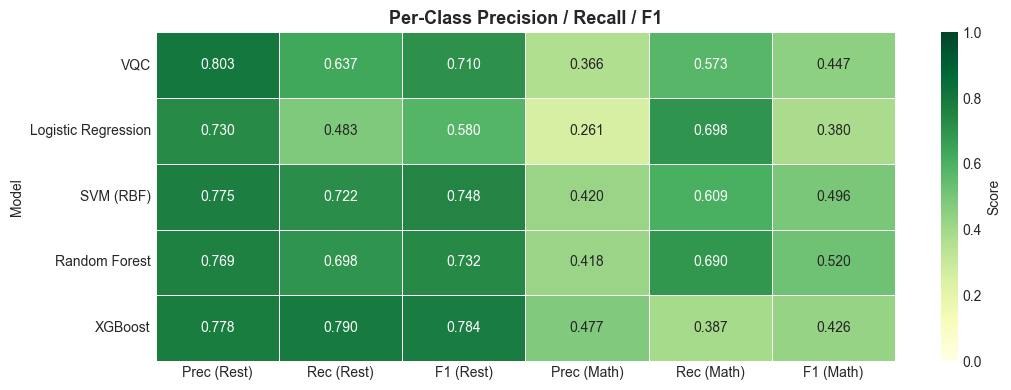

In [17]:
prec, rec, f1s, _ = precision_recall_fscore_support(y_test, y_pred_vqc, zero_division=0)
rows = [dict(Model='VQC',
             **{'Prec (Rest)': prec[0], 'Rec (Rest)': rec[0], 'F1 (Rest)': f1s[0],
                'Prec (Math)': prec[1], 'Rec (Math)': rec[1], 'F1 (Math)': f1s[1]})]

# Classical per-class from notebook 04
CLASSICAL_PC = {
    'Logistic Regression': (0.730, 0.483, 0.580, 0.261, 0.698, 0.380),
    'SVM (RBF)':           (0.775, 0.722, 0.748, 0.420, 0.609, 0.496),
    'Random Forest':       (0.769, 0.698, 0.732, 0.418, 0.690, 0.520),
    'XGBoost':             (0.778, 0.790, 0.784, 0.477, 0.387, 0.426),
}
for name, vals in CLASSICAL_PC.items():
    rows.append(dict(Model=name,
                     **{'Prec (Rest)': vals[0], 'Rec (Rest)': vals[1], 'F1 (Rest)': vals[2],
                        'Prec (Math)': vals[3], 'Rec (Math)': vals[4], 'F1 (Math)': vals[5]}))

pc_df = pd.DataFrame(rows).set_index('Model')
fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pc_df, annot=True, fmt='.3f', cmap='YlGn', vmin=0, vmax=1,
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Score'})
ax.set_title('Per-Class Precision / Recall / F1', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## Summary

### Final Metrics (3 413-sample training, 925-sample test)

| Model | Accuracy | F1 | AUC-ROC | Rec-level Acc |
|-------|----------|----|---------|---------------|
| **VQC (re-upload, 3L)** | 0.619 | 0.447 | 0.623 | 0.688 |
| Logistic Regression | 0.397 | 0.380 | 0.522 | 0.562 |
| SVM (RBF) | 0.685 | 0.496 | 0.698 | 0.750 |
| **Random Forest** | 0.665 | **0.520** | **0.711** | **0.812** |
| XGBoost | 0.694 | 0.426 | 0.653 | 0.688 |

### Why VQC Still Struggles vs Classical ML

- **45 parameters** vs RF (~100k nodes): severe capacity disadvantage on a 3 413-sample dataset
- **High inter-subject variability**: spectral features shift across subjects — a 45-param model cannot memorise per-subject offsets
- **Quantum advantage is theoretical** for this problem size; real hardware would add noise
- Classical tree ensembles exploit feature interactions that the shallow VQC misses

### When could VQC Win?

- Much larger qubit counts (>20) making the Hilbert space exponentially richer
- Kernel-based VQC (fixed encoding, no variational layers) when the quantum kernel is provably more expressive than classical kernels for the specific data geometry
- Problem instances with genuine quantum structure in the input data